In [15]:
import pandas as pd 
import seaborn as sns
import numpy as np
import os

%cd /home/varshini/uc_analyses/
import utils
%cd /home/varshini/LoopCall_Analysis_Scripts

import itertools

plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


/home/varshini/microc_analyses/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
load1 = np.load('/mnt/md0/varshini/Analysis/Blood/complete_analyses/hicrep/fine_5kb_2Mb_mat.npy')

In [3]:
cooler_names = os.listdir('/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/rep_cools')
cooler_names = [os.path.join('/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/rep_cools', c) for c in cooler_names if 'mcool' in c]

In [4]:
coolers = [utils.get_clr(clr_name, 50_000) for clr_name in cooler_names]
pairs = list(itertools.combinations(range(6), 2))

DEBUG:h5py._conv:Creating converter from 3 to 5


In [5]:
cooler_names 

['/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/rep_cools/Sankaran_Phase2_Rep1.250.mcool',
 '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/rep_cools/Sankaran_Phase3_Rep2.250.mcool',
 '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/rep_cools/Sankaran_Phase3_Rep1.250.mcool',
 '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/rep_cools/Sankaran_Phase2_Rep2.250.mcool',
 '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/rep_cools/Sankaran_Phase1_Rep2.250.mcool',
 '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/rep_cools/Sankaran_Phase1_Rep1.250.mcool']

In [6]:
pd.DataFrame(load1)

,0,1,2,3,4,5
0,1.000000,0.844392,0.882646,0.877674,0.821665,0.911138
1,0.844392,1.000000,0.941717,0.946157,0.802535,0.834403
2,0.882646,0.941717,1.000000,0.904459,0.756164,0.813243
3,0.877674,0.946157,0.904459,1.000000,0.911233,0.902382
4,0.821665,0.802535,0.756164,0.911233,1.000000,0.915542
5,0.911138,0.834403,0.813243,0.902382,0.915542,1.000000


In [7]:
scc_mat_df

NameError: name 'scc_mat_df' is not defined

DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x7fe31ebcf160>


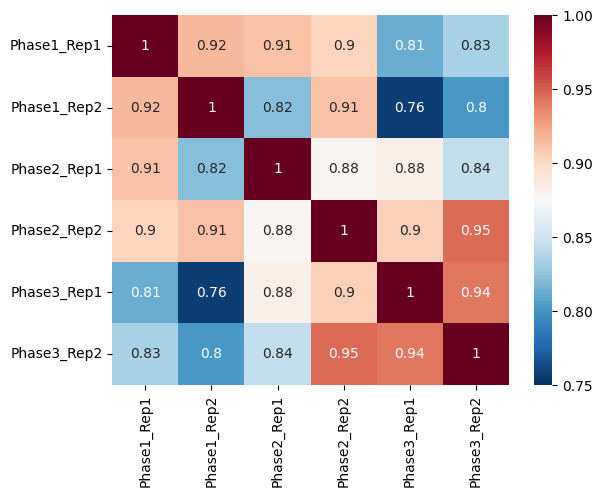

In [19]:
scc_mat_df = pd.DataFrame(load1)
scc_mat_df.index = [cooler_names[i].split('/')[-1].split('.')[-3].split('Sankaran_')[-1] for i in scc_mat_df.index]
scc_mat_df.columns = scc_mat_df.index
sorted_idx = sorted(scc_mat_df.index)
scc_mat_df_sorted = scc_mat_df.loc[sorted_idx, sorted_idx]
fig = sns.heatmap(scc_mat_df_sorted, cmap=sns.color_palette("RdBu_r", as_cmap=True), annot=True, vmin=0.75).get_figure()

In [20]:
import matplotlib.pyplot as plt
fig.savefig("/mnt/md0/varshini/Analysis/Blood/figs_v2/supp1/repro_5kb_2Mb.svg")